In [3]:
'''
Evaluate the performance of search algorithms 
Collect scores across all prompts and trials, and compute the overall statistics.
'''

import os, psutil, gc
import time
import re
import json
import pprint
import importlib

import logging
logging.basicConfig(format='%(message)s', level=logging.FATAL+1)

import random
import numpy as np
np.set_printoptions(precision=4)

from utils import metrics 

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("ticks")
sns.set_style("whitegrid")
sns.set_palette("tab20")
colors = sns.color_palette("bright")


#### Level 3

In [ ]:

level = 3 

num_trials = 5
step_budget = 200
step_idxes = np.linspace(0, 199, 21, dtype=int)

if level == 3:
    config_names = [
        # "mcts--level-3--e21--n-4--d-20--nb-4--cpuct-2",
        # "mcts--level-3--e21--n-4--d-20--nb-10--cpuct-2",
        # "mcts--level-3--e21--n-4--d-10--nb-8--cpuct-2",
        # "mcts--level-3--e21--n-4--d-10--nb-12--cpuct-2",
        "mcts--level-3--e31--n-4--d-20--nb-4--cpuct-2",
        "mcts--level-3--e31--n-4--d-20--nb-10--cpuct-2",
        # "mcts--level-3--e31--n-4--d-10--nb-8--cpuct-2",
        # "mcts--level-3--e31--n-4--d-10--nb-12--cpuct-2",
        # "mcts--level-3--e31--n-4--d-10--nb-10--cpuct-2",
        # "mcts--level-3--e31--n-4--d-10--nb-20--cpuct-2",
        # "mcts--level-3--e61--n-4--d-20--nb-4--lam-0.01--dalpha-100.0--dbeta-1.0--ppl-True--normalize-True",
        # "mcts--level-3--e61--n-4--d-20--nb-10--lam-0.01--dalpha-100.0--dbeta-1.0--ppl-True--normalize-True",
        # "mcts--level-3--e61--n-4--d-10--nb-8--lam-0.01--dalpha-100.0--dbeta-1.0--ppl-True--normalize-True",
        # "mcts--level-3--e61--n-4--d-10--nb-12--lam-0.01--dalpha-100.0--dbeta-1.0--ppl-True--normalize-True",
        "mcts--level-3--e71--n-4--d-20--nb-4--lam-0.01--dalpha-100.0--dbeta-1.0--ppl-True--normalize-True",
        "mcts--level-3--e71--n-4--d-20--nb-10--lam-0.01--dalpha-100.0--dbeta-1.0--ppl-True--normalize-True",
        # "mcts--level-3--e71--n-4--d-10--nb-8--lam-0.01--dalpha-100.0--dbeta-1.0--ppl-True--normalize-True",
        # "mcts--level-3--e71--n-4--d-10--nb-12--lam-0.01--dalpha-100.0--dbeta-1.0--ppl-True--normalize-True",
        # "mcts--level-3--e71--n-4--d-10--nb-10--lam-0.01--dalpha-100.0--dbeta-1.0--ppl-True--normalize-True",
    ]

    config_names = [
        # "mcts--level-3--h71--n-4--d-20--b-80--lam-0.01--dalpha-1.0--dbeta-1.0--ppl-True--normalize-True",
        # "mcts--level-3--h71--n-4--d-20--b-80--lam-0.01--dalpha-10.0--dbeta-1.0--ppl-True--normalize-True",
        # "mcts--level-3--h71--n-4--d-20--b-80--lam-0.01--dalpha-100.0--dbeta-1.0--ppl-True--normalize-True",
        # "mcts--level-3--h71--n-4--d-20--b-80--lam-0.01--dalpha-1000.0--dbeta-1.0--ppl-True--normalize-True",
        # "mcts--level-3--h71--n-4--d-20--b-80--lam-0.1--dalpha-1.0--dbeta-1.0--ppl-True--normalize-True",
        # "mcts--level-3--h71--n-4--d-20--b-80--lam-0.1--dalpha-10.0--dbeta-1.0--ppl-True--normalize-True",
        # "mcts--level-3--h71--n-4--d-20--b-80--lam-0.1--dalpha-100.0--dbeta-1.0--ppl-True--normalize-True",
        # "mcts--level-3--h71--n-4--d-20--b-80--lam-0.1--dalpha-1000.0--dbeta-1.0--ppl-True--normalize-True",
        # "mcts--level-3--h71--n-4--d-20--b-80--lam-1.0--dalpha-1.0--dbeta-1.0--ppl-True--normalize-True",
        # "mcts--level-3--h71--n-4--d-20--b-80--lam-1.0--dalpha-10.0--dbeta-1.0--ppl-True--normalize-True",
        # "mcts--level-3--h71--n-4--d-20--b-80--lam-1.0--dalpha-100.0--dbeta-1.0--ppl-True--normalize-True",
        # "mcts--level-3--h71--n-4--d-20--b-80--lam-1.0--dalpha-1000.0--dbeta-1.0--ppl-True--normalize-True",
        # "mcts--level-3--h72--n-4--d-20--b-80--lam-0.01--dalpha-1.0--dbeta-1.0--ppl-True--normalize-True",
        # "mcts--level-3--h72--n-4--d-20--b-80--lam-0.01--dalpha-10.0--dbeta-1.0--ppl-True--normalize-True",
        # "mcts--level-3--h72--n-4--d-20--b-80--lam-0.01--dalpha-100.0--dbeta-1.0--ppl-True--normalize-True",
        # "mcts--level-3--h72--n-4--d-20--b-80--lam-0.01--dalpha-1000.0--dbeta-1.0--ppl-True--normalize-True",
        "mcts--level-3--h73--n-4--d-20--b-80--lam-0.01--dalpha-1.0--dbeta-1.0--ppl-True--normalize-True",
        "mcts--level-3--h73--n-4--d-20--b-80--lam-0.01--dalpha-10.0--dbeta-1.0--ppl-True--normalize-True",
        "mcts--level-3--h73--n-4--d-20--b-80--lam-0.01--dalpha-100.0--dbeta-1.0--ppl-True--normalize-True",
        "mcts--level-3--h73--n-4--d-20--b-80--lam-0.01--dalpha-1000.0--dbeta-1.0--ppl-True--normalize-True",
    ]

#### Level 4


-> config_name = mcts--level-4--e21--n-4--d-20--nb-4--cpuct-2
(640, 400)
peak1b_score = 0.4375 (±0.0196)

-> config_name = mcts--level-4--e21--n-4--d-20--nb-8--cpuct-2
(640, 400)
peak1b_score = 0.4703 (±0.0197)

-> config_name = mcts--level-4--e61--n-4--d-20--nb-4--lam-0.01--dalpha-100.0--dbeta-1.0--ppl-True--normalize-True
(640, 400)
peak1b_score = 0.4375 (±0.0196)

-> config_name = mcts--level-4--e61--n-4--d-20--nb-8--lam-0.01--dalpha-100.0--dbeta-1.0--ppl-True--normalize-True
(640, 400)
peak1b_score = 0.4688 (±0.0197)


[]

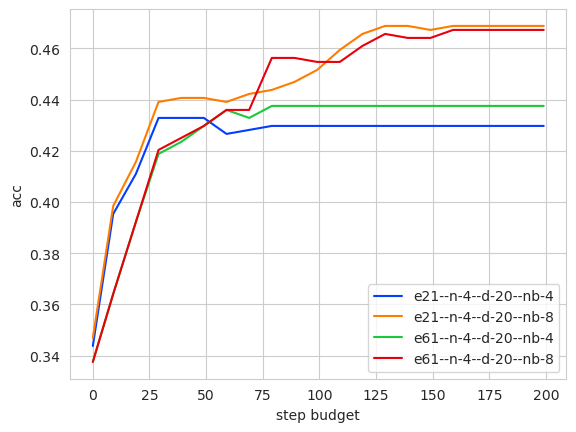

In [7]:
level = 4
num_trials = 5
step_budget = 400
step_idxes = np.linspace(0, 199, 21, dtype=int)

if level == 4:
    config_names = [
        "mcts--level-4--e21--n-4--d-20--nb-4--cpuct-2",
        "mcts--level-4--e21--n-4--d-20--nb-8--cpuct-2",
        # "mcts--level-4--e21--n-4--d-10--nb-8--cpuct-2",
        # "mcts--level-4--e21--n-4--d-10--nb-12--cpuct-2",
        # "mcts--level-4--e31--n-4--d-20--nb-4--cpuct-2",
        # "mcts--level-4--e31--n-4--d-20--nb-8--cpuct-2",
        # "mcts--level-4--e31--n-4--d-20--nb-10--cpuct-2",
        # "mcts--level-4--e31--n-4--d-10--nb-8--cpuct-2",
        # "mcts--level-4--e31--n-4--d-10--nb-12--cpuct-2",
        "mcts--level-4--e61--n-4--d-20--nb-4--lam-0.01--dalpha-100.0--dbeta-1.0--ppl-True--normalize-True",
        "mcts--level-4--e61--n-4--d-20--nb-8--lam-0.01--dalpha-100.0--dbeta-1.0--ppl-True--normalize-True",
        # "mcts--level-4--e61--n-4--d-10--nb-8--lam-0.01--dalpha-100.0--dbeta-1.0--ppl-True--normalize-True",
        # "mcts--level-4--e61--n-4--d-10--nb-12--lam-0.01--dalpha-100.0--dbeta-1.0--ppl-True--normalize-True",
        # "mcts--level-4--e71--n-4--d-20--nb-4--lam-0.01--dalpha-100.0--dbeta-1.0--ppl-True--normalize-True",
        # "mcts--level-4--e71--n-4--d-20--nb-8--lam-0.01--dalpha-100.0--dbeta-1.0--ppl-True--normalize-True",
        # "mcts--level-4--e71--n-4--d-20--nb-10--lam-0.01--dalpha-100.0--dbeta-1.0--ppl-True--normalize-True",
        # "mcts--level-4--e71--n-4--d-10--nb-8--lam-0.01--dalpha-100.0--dbeta-1.0--ppl-True--normalize-True",
        # "mcts--level-4--e71--n-4--d-10--nb-12--lam-0.01--dalpha-100.0--dbeta-1.0--ppl-True--normalize-True",
    ]
    
    # config_names = [
    #     "mcts--level-4--e31--n-4--d-40--nb-2--cpuct-2",
    #     "mcts--level-4--e71--n-4--d-40--nb-2--lam-0.01--dalpha-100.0--dbeta-1.0--ppl-True--normalize-True",
    # ]
  
importlib.reload(metrics)

for cidx, config_name in enumerate(config_names):
    print(f"\n-> config_name = {config_name}")
    result_dir = f"results/mcts--level-{level}/{config_name}"    
    peak1b_correctnes_mean, peak1b_correctness_std = \
        metrics.compute_stats_correctness_curve_budget(result_dir, config_name, num_trials, step_budget)

    match = re.search(r'(e\d+--n-\d+--d-\d+--nb-\d+)', config_name)
    if match:
        config_label = match.group(1)
    else:
        config_label = config_name
        
    plt.plot(step_idxes, peak1b_correctnes_mean[step_idxes], color=colors[cidx], label=config_label) 
    # plt.plot(step_idxes, peak1b_correctnes_mean[step_idxes] + peak1b_correctness_std[step_idxes], color=colors[cidx], alpha=0.4)
    # plt.plot(step_idxes, peak1b_correctnes_mean[step_idxes] - peak1b_correctness_std[step_idxes], color=colors[cidx], alpha=0.4)

plt.ylabel(f"acc")
plt.xlabel(f"step budget")
# plt.xticks(step_idxes)
plt.legend()
plt.plot()

#### Level 5

In [ ]:
if level == 5:
    config_names = [
        # "mcts--level-5--e21--n-4--d-10--nb-8--cpuct-2",
        # "mcts--level-5--e21--n-4--d-10--nb-12--cpuct-2",
        # "mcts--level-5--e21--n-4--d-20--nb-4--cpuct-2",
        # "mcts--level-5--e21--n-4--d-20--nb-8--cpuct-2",
        # "mcts--level-5--e31--n-4--d-20--nb-4--cpuct-2",
        # "mcts--level-5--e31--n-4--d-20--nb-8--cpuct-2",
        # "mcts--level-5--e31--n-4--d-10--nb-8--cpuct-2",
        # "mcts--level-5--e31--n-4--d-10--nb-12--cpuct-2",
        # "mcts--level-5--e31--n-8--d-20--nb-4--cpuct-2",
        # "mcts--level-5--e31--n-8--d-20--nb-8--cpuct-2",
        # "mcts--level-5--e61--n-4--d-10--nb-8--lam-0.01--dalpha-100.0--dbeta-1.0--ppl-True--normalize-True",
        # "mcts--level-5--e61--n-4--d-10--nb-12--lam-0.01--dalpha-100.0--dbeta-1.0--ppl-True--normalize-True",
        # "mcts--level-5--e61--n-4--d-20--nb-4--lam-0.01--dalpha-100.0--dbeta-1.0--ppl-True--normalize-True",
        # "mcts--level-5--e61--n-4--d-20--nb-8--lam-0.01--dalpha-100.0--dbeta-1.0--ppl-True--normalize-True",
        # "mcts--level-5--e71--n-4--d-20--nb-4--lam-0.01--dalpha-100.0--dbeta-1.0--ppl-True--normalize-True",
        # "mcts--level-5--e71--n-4--d-20--nb-8--lam-0.01--dalpha-100.0--dbeta-1.0--ppl-True--normalize-True",
        # "mcts--level-5--e71--n-4--d-10--nb-8--lam-0.01--dalpha-100.0--dbeta-1.0--ppl-True--normalize-True",
        "mcts--level-5--e71--n-4--d-10--nb-12--lam-0.01--dalpha-100.0--dbeta-1.0--ppl-True--normalize-True",
        # "mcts--level-5--e71--n-8--d-20--nb-4--lam-0.01--dalpha-100.0--dbeta-1.0--ppl-True--normalize-True",
        # "mcts--level-5--e71--n-8--d-20--nb-8--lam-0.01--dalpha-100.0--dbeta-1.0--ppl-True--normalize-True",
    ]
